In [43]:
import pandas as pd
import numpy as np
from tensorflow import keras
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GroupKFold
import pickle

In [44]:
data_path = "/Users/harry/Documents/3rd Year/Project/Storm_building/storm_dataset_96.csv"
storms = pd.read_csv(data_path)

MAX_LAG = 10
N_FEATURES = 5
BATCH_SIZE = 64
EPOCHS = 32
PATIENCE = 4
EXCLUDE = ["Datetime","storm_number", "Dst_t+3"]
INCLUDE = [col for col in storms.columns if col not in EXCLUDE]

print(f"Storm labels (unique storms):\n{storms['storm_number'].unique()}")
print(f"Shape of data set: {storms.shape}")

Storm labels (unique storms):
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]
Shape of data set: (9700, 53)


In [45]:
storms.columns

Index(['Datetime', 'Bz_GSM_t-9', 'Bz_GSM_t-8', 'Bz_GSM_t-7', 'Bz_GSM_t-6',
       'Bz_GSM_t-5', 'Bz_GSM_t-4', 'Bz_GSM_t-3', 'Bz_GSM_t-2', 'Bz_GSM_t-1',
       'Bz_GSM_t-0', 'Bz_GSE_t-9', 'Bz_GSE_t-8', 'Bz_GSE_t-7', 'Bz_GSE_t-6',
       'Bz_GSE_t-5', 'Bz_GSE_t-4', 'Bz_GSE_t-3', 'Bz_GSE_t-2', 'Bz_GSE_t-1',
       'Bz_GSE_t-0', 'Plasma_Speed_t-9', 'Plasma_Speed_t-8',
       'Plasma_Speed_t-7', 'Plasma_Speed_t-6', 'Plasma_Speed_t-5',
       'Plasma_Speed_t-4', 'Plasma_Speed_t-3', 'Plasma_Speed_t-2',
       'Plasma_Speed_t-1', 'Plasma_Speed_t-0', 'Field_Mag_Avg_t-9',
       'Field_Mag_Avg_t-8', 'Field_Mag_Avg_t-7', 'Field_Mag_Avg_t-6',
       'Field_Mag_Avg_t-5', 'Field_Mag_Avg_t-4', 'Field_Mag_Avg_t-3',
       'Field_Mag_Avg_t-2', 'Field_Mag_Avg_t-1', 'Field_Mag_Avg_t-0',
       'Proton_Density_t-9', 'Proton_Density_t-8', 'Proton_Density_t-7',
       'Proton_Density_t-6', 'Proton_Density_t-5', 'Proton_Density_t-4',
       'Proton_Density_t-3', 'Proton_Density_t-2', 'Proton_Density_t-1',
  

In [46]:
"""def train_model(max_lag, n_features):
    model = keras.Sequential([
        keras.layers.Input(shape = (max_lag, n_features)),
        keras.layers.LSTM(64, return_sequences = True, dropout = 0.2, recurrent_dropout = 0.1),
        keras.layers.LSTM(32, dropout = 0.2),
        keras.layers.Dense(16, activation = "relu"),
        keras.layers.Dense(1)])
    model.compile(optimizer = "adam", loss = "mse", metrics = ["mae"])
    return model"""

def train_model(max_lag, n_features):
    model = keras.Sequential([
        keras.layers.Input(shape=(max_lag, n_features)),
        keras.layers.LayerNormalization(),
        keras.layers.LSTM(64, return_sequences = True, dropout = 0.2, recurrent_dropout = 0.1),
        keras.layers.LSTM(32, dropout = 0.2),
        keras.layers.Dense(16, activation = "relu"),
        keras.layers.Dense(1)
    ])
    
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
        loss = keras.losses.Huber(delta = 20.0),
        metrics = ["mae"]
    )
    return model



def sequence(X_flat, n_features = 5, max_lag = 10):

    n = X_flat.shape[0]
    X = X_flat.reshape(n, n_features, max_lag)
    X = X.transpose(0, 2, 1)
    return X

def scale_data(x, y, x_scaler = None, y_scaler = None, fit = False):
    if fit:
        x_scaler = MinMaxScaler()
        y_scaler = MinMaxScaler()
        X_scaled = x_scaler.fit_transform(x)
        Y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()
    else:
        X_scaled = x_scaler.transform(x)
        Y_scaled = y_scaler.transform(y.reshape(-1, 1)).ravel()
    return X_scaled, Y_scaled, x_scaler, y_scaler

def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {"mse": mse, "mae": mae, "rmse": rmse}

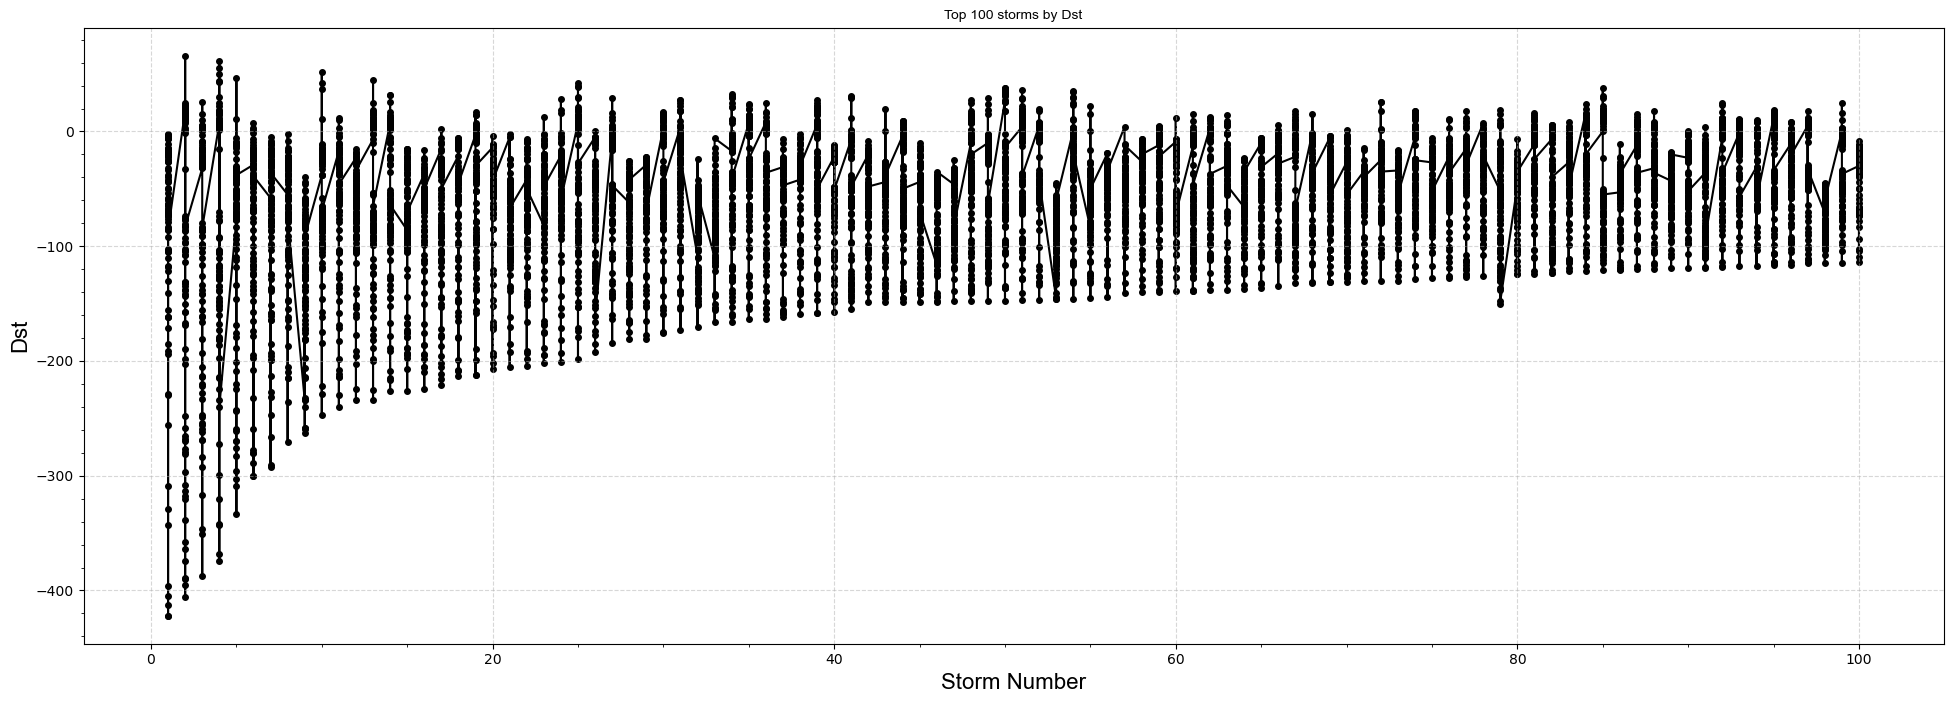

In [47]:
plt.figure(figsize = (24, 8))
plt.title("Top 100 storms by Dst", fontsize = 20, font = "Arial")
plt.plot(storms["storm_number"], storms["Dst_t+3"], color = "black", marker = "o", markersize = 4, linestyle = "-", zorder = 1)
plt.xlabel("Storm Number", fontsize = 16, font = "Arial")
plt.ylabel("Dst", fontsize = 16, font = "Arial")
plt.minorticks_on()
plt.grid(linestyle = "--", alpha = 0.5, zorder = 0)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


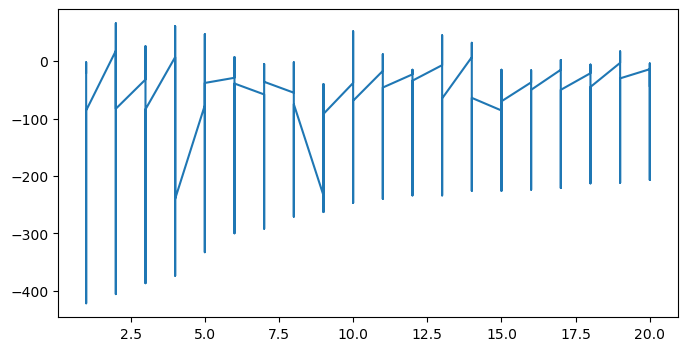

In [48]:
top_20 = storms[storms["storm_number"] < 21]
len(top_20["storm_number"].unique())

plt.figure(figsize = (8, 4))
plt.plot(top_20["storm_number"], top_20["Dst_t+3"])

print(top_20.storm_number.unique())

In [49]:
CV = GroupKFold(n_splits = 4)

outer_scores = []
output = {}

for test_storm in top_20.storm_number.unique():
    test_data = storms.loc[storms["storm_number"] == test_storm].copy()
    Xtest = test_data[INCLUDE].values
    ytest = test_data["Dst_t+3"].values

    train_data = storms.loc[storms["storm_number"] != test_storm].copy()
    X = train_data[INCLUDE].values
    y = train_data["Dst_t+3"].values

    groups = train_data["storm_number"].values
    best_model = None
    best_score = np.inf
    best_history = None
    best_x_scaler = None
    best_y_scaler = None

    for fold , (train_idx, val_idx) in enumerate(CV.split(X, y, groups)):
        Xtrain = X[train_idx]
        Xval = X[val_idx]
        ytrain = y[train_idx]
        yval = y[val_idx]

        Xtrain_scaled, ytrain_scaled, x_scaler, y_scaler = scale_data(Xtrain, ytrain, fit = True)
        Xval_scaled, yval_scaled, _, _ = scale_data(Xval, yval, x_scaler = x_scaler, y_scaler = y_scaler, fit = False)

        Xtrain_seq = sequence(Xtrain_scaled)
        Xval_seq = sequence(Xval_scaled)

        model = train_model(max_lag = MAX_LAG, n_features = N_FEATURES)
        callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = PATIENCE, restore_best_weights = True),
                     keras.callbacks.ReduceLROnPlateau(monitor = "val_loss", factor = 0.5, patience = PATIENCE)]
        
        history = model.fit(Xtrain_seq,
                            ytrain_scaled,
                            validation_data = (Xval_seq, yval_scaled),
                            epochs = EPOCHS,
                            callbacks = callbacks,
                            batch_size = BATCH_SIZE,
                            verbose = 0)
        
        yval_pred = model.predict(Xval_seq)
        yval_pred = y_scaler.inverse_transform(yval_pred.reshape(-1, 1)).ravel()

        score = np.sqrt(mean_squared_error(yval, yval_pred))

        if score < best_score:
            best_model = model
            best_history = history
            best_score = score
            best_x_scaler = x_scaler
            best_y_scaler = y_scaler
    
    Xtest_scaled, ytest_scaled, _, _ = scale_data(Xtest, ytest, x_scaler = best_x_scaler, y_scaler = best_y_scaler, fit = False)
    Xtest_seq = sequence(Xtest_scaled)

    ytest_pred = best_model.predict(Xtest_seq)
    ytest_pred = best_y_scaler.inverse_transform(ytest_pred.reshape(-1, 1)).ravel()
    test_score = np.sqrt(mean_squared_error(ytest, ytest_pred))
    output[test_storm] = {"y_true": ytest, "y_pred": ytest_pred}
    outer_scores.append(test_score)

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/s

In [50]:
print(best_score)

30.514349336510882


In [51]:
best_history_df = pd.DataFrame(best_history.history)

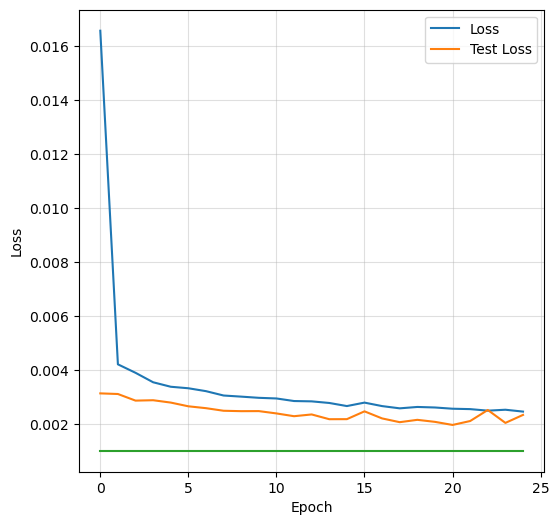

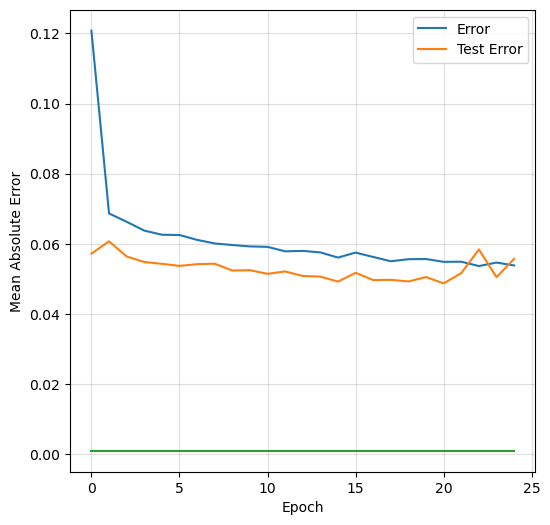

In [52]:
plt.figure(figsize= (6, 6))

plt.plot(best_history_df["loss"], label = "Loss")
plt.plot(best_history_df["val_loss"], label = "Test Loss")
plt.plot(best_history_df["learning_rate"])
plt.grid(alpha = 0.4)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize= (6, 6))

plt.plot(best_history_df["mae"], label = "Error")
plt.plot(best_history_df["val_mae"], label = "Test Error")
plt.plot(best_history_df["learning_rate"])
plt.grid(alpha = 0.4)
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.show()

In [53]:
outer_scores

[np.float64(53.95877187282872),
 np.float64(61.485795844354534),
 np.float64(44.66168925923368),
 np.float64(55.18443522475344),
 np.float64(34.25131827622075),
 np.float64(41.05601759682341),
 np.float64(44.73412805747477),
 np.float64(28.97806309491097),
 np.float64(41.067703512800605),
 np.float64(42.43754409935533),
 np.float64(34.0510594985445),
 np.float64(24.974750365601846),
 np.float64(38.386340371586606),
 np.float64(49.206827050725714),
 np.float64(26.99594105715012),
 np.float64(23.935966585786463),
 np.float64(27.328385274808877),
 np.float64(31.095352009180584),
 np.float64(38.64936158153542),
 np.float64(25.379568444201496)]

In [54]:
output

{np.int64(1): {'y_true': array([ -20.,  -16.,  -15.,  -17.,  -15.,  -18.,  -18.,  -18.,  -22.,
          -27.,  -26.,  -26.,  -25.,  -21.,  -17.,  -16.,  -17.,  -21.,
          -18.,  -17.,  -14.,  -16.,  -11.,   -6.,   -6.,   -3.,   -2.,
           -4.,   -4.,   -6.,   -5.,   -7.,  -15.,  -26.,  -32.,  -34.,
          -17.,  -38.,  -68.,  -58.,  -49., -102., -162., -171., -229.,
         -329., -396., -413., -422., -422., -405., -343., -309., -256.,
         -230., -194., -191., -185., -156., -162., -162., -141., -130.,
         -122., -118., -117., -110., -104., -105., -104.,  -92.,  -86.,
          -83.,  -76.,  -69.,  -63.,  -60.,  -71.,  -79.,  -74.,  -68.,
          -70.,  -74.,  -69.,  -65.,  -59.,  -50.,  -44.,  -42.,  -40.,
          -43.,  -54.,  -63.,  -64.,  -72.,  -85.,  -86.]),
  'y_pred': array([ -68.52956 ,  -67.53423 ,  -67.62473 ,  -67.50075 ,  -66.12758 ,
          -64.86622 ,  -64.33443 ,  -62.598557,  -61.432735,  -59.487057,
          -57.44741 ,  -56.791534,  -56

In [55]:
output_batch = pd.DataFrame(output).T
output_batch.head()

,y_true,y_pred
1,"[-20.0, -16.0, -15.0, -17.0, -15.0, -18.0, -18...","[-68.52956, -67.53423, -67.62473, -67.50075, -..."
2,"[18.0, 15.0, 15.0, 14.0, 14.0, 13.0, 14.0, 15....","[-36.471947, -36.37764, -36.42968, -36.445446,..."
3,"[-32.0, -30.0, -23.0, -28.0, -27.0, -28.0, -28...","[-53.07134, -51.230244, -50.056087, -49.131584..."
4,"[7.0, 7.0, 6.0, 6.0, 6.0, 6.0, 7.0, 7.0, 5.0, ...","[-34.862484, -34.969208, -34.97636, -34.917633..."
5,"[-77.0, -70.0, -66.0, -76.0, -83.0, -66.0, -56...","[-41.400093, -42.51442, -41.872, -39.978493, -..."


In [56]:
output_batch.to_csv("batch_output.csv", index = False)

In [57]:
with open("batch_output_96.pkl", "wb") as f:
    pickle.dump(output_batch, f)